In [1]:
import os
import sys

# --- CONFIGURATION ---
REPO_NAME = "RefraScan"
# Make sure your username and repo name are spelled EXACTLY as they appear on GitHub
GITHUB_USER = "Kyziapi" 
BRANCH_NAME = "main"  
# ---------------------

REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"
REPO_PATH = os.path.join("/kaggle/working", REPO_NAME)

if not os.path.exists(REPO_NAME):
    print(f"Cloning branch '{BRANCH_NAME}' from {REPO_NAME}...")
    # env={"GIT_TERMINAL_PROMPT": "0"} tells Git to instantly fail instead of hanging if it can't find the repo
    !env GIT_TERMINAL_PROMPT=0 git clone -b {BRANCH_NAME} {REPO_URL}
else:
    print(f"{REPO_NAME} already exists. Switching branch and pulling latest updates...")
    !cd {REPO_NAME} && env GIT_TERMINAL_PROMPT=0 git fetch --all && git checkout {BRANCH_NAME} && git pull origin {BRANCH_NAME}

# Add the repository root to sys.path so Python can find the 'src' package
if os.path.exists(REPO_PATH):
    if REPO_PATH not in sys.path:
        sys.path.append(REPO_PATH)
    
    # Import your modular components
    import math
    import pandas as pd
    from tensorflow.keras.applications.efficientnet import preprocess_input

    try:
        from src.preprocessing import load_and_clean_data, calculate_class_weights, scale_age_feature, split_data_by_patient, create_multimodal_generator
        from src.models import build_efficientnet
        from src.train import train_model
        print("🚀 Success! Custom modules imported smoothly.")
    except ModuleNotFoundError as e:
        print(f"❌ Still failing. Current sys.path contains: {sys.path}")
        raise e

    print(f"Environment configured successfully! Working on branch: {BRANCH_NAME}")
else:
    print("❌ Error: Repository failed to clone. Double check your GITHUB_USER name and ensure the branch 'preprocessing_test' actually exists on GitHub.")

Cloning branch 'main' from RefraScan...
Cloning into 'RefraScan'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 245 (delta 10), reused 23 (delta 9), pack-reused 219 (from 1)
Receiving objects: 100% (245/245), 50.18 KiB | 1.52 MiB/s, done.
Resolving deltas: 100% (112/112), done.
🚀 Success! Custom modules imported smoothly.
Environment configured successfully! Working on branch: main


In [2]:
import inspect
print(inspect.signature(create_multimodal_generator))

(df, metadata_cols, class_weights, batch_size=16, target_size=(300, 300), augment=False, preprocess_fn=None, image_loader=None)


In [3]:
# Configure paths relative to Kaggle's input directory
DATASET_DIR = '/kaggle/input/datasets/yerikaelainegueco/fundus-images-with-refractive-values' 
CSV_PATH = os.path.join(DATASET_DIR, 'RefraScan_dataset.csv')
IMG_DIR = os.path.join(DATASET_DIR, 'FundusImages')

# 1. Load and clean data
df = load_and_clean_data(CSV_PATH, IMG_DIR)
numerical_features = ['age'] 
categorical_features = ['data_origin'] 

# 2. Map targets
df['classification_encoded'] = df['classification'].map({'Emmetropia': 0, 'Myopia': 1, 'Hyperopia': 2})

# 4. Perform stratified patient split (70% Train, 15% Val, 15% Test)
train_df, val_df, test_df = split_data_by_patient(df, patient_col='ID', target_col='classification_encoded')

# 5. Calculate Class Weights
class_weights = calculate_class_weights(train_df, 'classification_encoded')
print("class_weights: ",class_weights)

# 6. Create Multimodal Generators
metadata_cols = numerical_features + categorical_features

train_gen = create_multimodal_generator(
    train_df, 
    metadata_cols, 
    class_weights,
    batch_size=16, 
    augment=True, 
    preprocess_fn=preprocess_input
)

val_gen = create_multimodal_generator(
    val_df, 
    metadata_cols,
    class_weights,
    batch_size=16, 
    augment=False, 
    preprocess_fn=preprocess_input
)

class_weights:  {np.int64(0): np.float64(2.925925925925926), np.int64(1): np.float64(0.5152173913043478), np.int64(2): np.float64(1.3941176470588235)}


Batch Images Shape: (16, 300, 300, 3)
Batch Metadata Shape: (16, 3)
Batch Labels Shape: (16,)


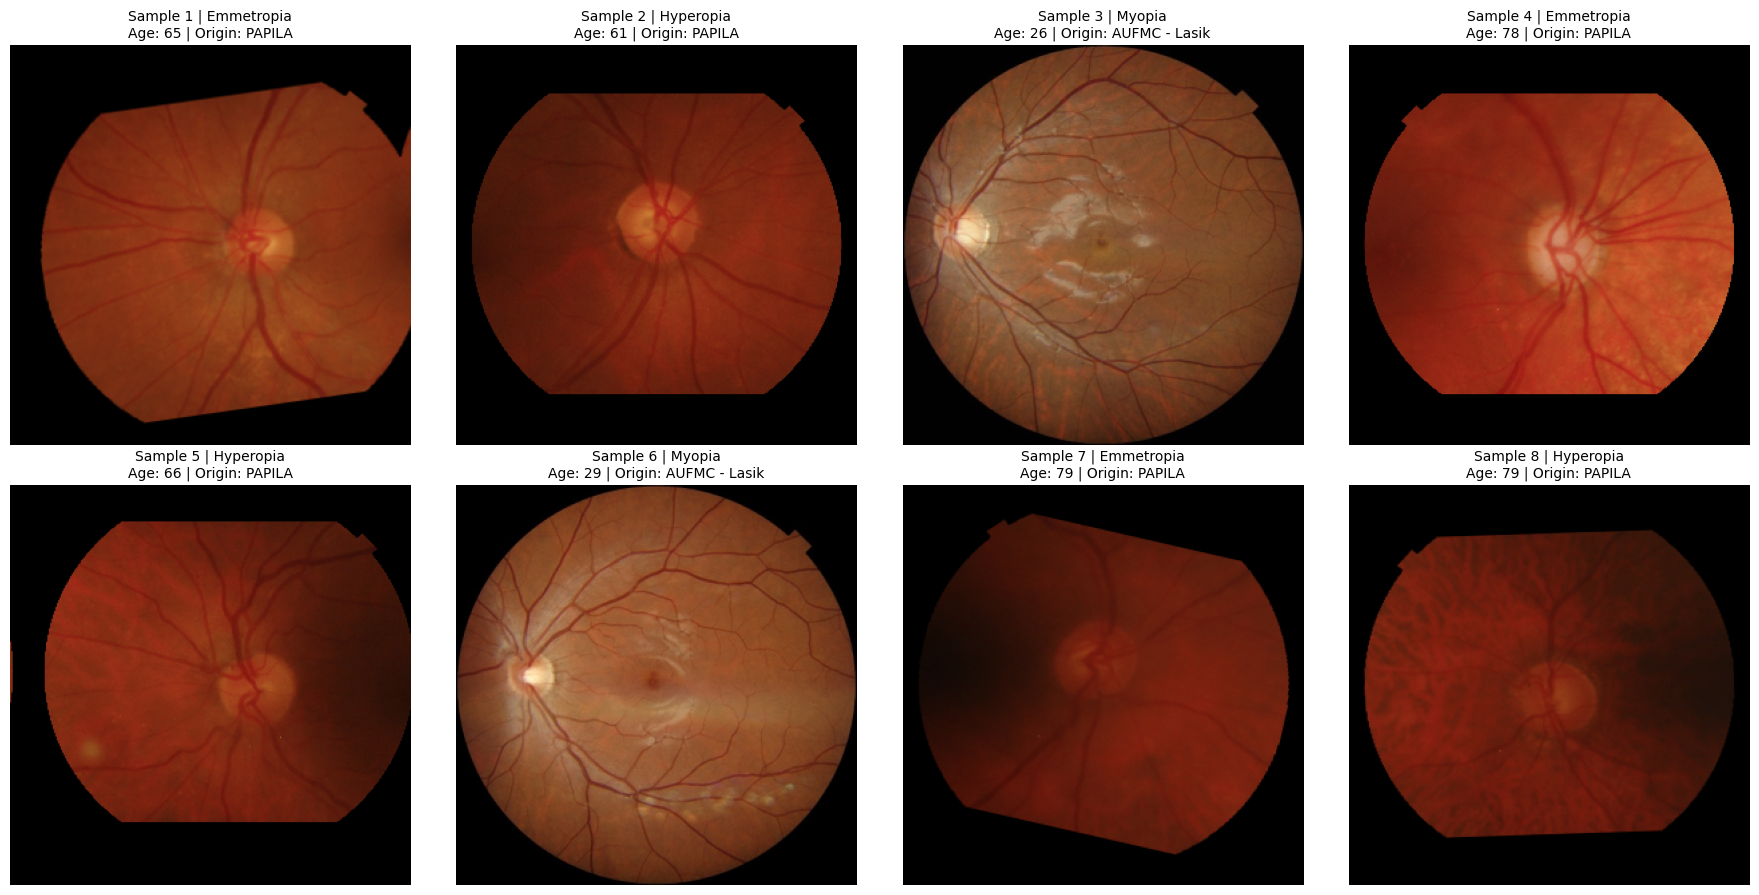

In [4]:
# View preprocessing results

import matplotlib.pyplot as plt
import numpy as np

# 1. Fetch a single batch from your multimodal training generator
# Returns: [batch_images, batch_metadata], batch_labels
(sample_images, sample_metadata), sample_labels = next(train_gen)

print(f"Batch Images Shape: {sample_images.shape}")    # Expected: (16, 300, 300, 3)
print(f"Batch Metadata Shape: {sample_metadata.shape}")  # Expected: (16, num_metadata_features)
print(f"Batch Labels Shape: {sample_labels.shape}")      # Expected: (16,)

# Re-construct metadata column structure to easily parse age and data_origin
# Age is the first numerical feature (index 0)
# One-hot encoded data_origin categories follow age
origin_categories = sorted(train_df['data_origin'].unique())

# 2. Visualize a grid of images from the batch to inspect preprocessing, age, and data_origin
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Class mapping dictionary for title readability
class_map = {0: 'Emmetropia', 1: 'Myopia', 2: 'Hyperopia'}

for i in range(min(8, len(sample_images))):
    img = sample_images[i].copy()
    meta = sample_metadata[i]
    
    # Extract age (index 0)
    age = int(meta[0])
    
    # Extract data_origin from the one-hot encoded vector (indices 1 onwards)
    one_hot_origin = meta[1:]
    origin_idx = np.argmax(one_hot_origin)
    origin_name = origin_categories[origin_idx]
    
    # Label class name
    label_num = sample_labels[i]
    label_name = class_map.get(label_num, f"Class {label_num}")
    
    # Rescale back to [0, 255] if preprocessed for model
    if img.min() < 0 or img.max() <= 1.0:
        img = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
        
    axes[i].imshow(img)
    axes[i].set_title(f"Sample {i+1} | {label_name}\nAge: {age} | Origin: {origin_name}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Verify patient and image counts
print(f"Train Set: {train_df['ID'].nunique()} Patients -> {len(train_df)} Images")
print(f"Val Set:   {val_df['ID'].nunique()} Patients -> {len(val_df)} Images")
print(f"Test Set:  {test_df['ID'].nunique()} Patients -> {len(test_df)} Images")

# Confirm zero patient overlap across splits
overlap = set(train_df['ID']).intersection(set(val_df['ID'])).union(set(train_df['ID']).intersection(set(test_df['ID'])))
print(f"Patient Overlap Count: {len(overlap)} (Must be 0)")

Train Set: 361 Patients -> 711 Images
Val Set:   78 Patients -> 152 Images
Test Set:  78 Patients -> 155 Images
Patient Overlap Count: 0 (Must be 0)


In [6]:
# Total original images in the full dataset
total_original = len(df)
print(f"Total Original Images: {total_original}")

# Original images in training split
print(f"Original Training Images: {len(train_df)}")
print(f"Original Validation Images: {len(val_df)}")

Total Original Images: 1018
Original Training Images: 711
Original Validation Images: 152


In [7]:
# Total augmented images
import math

batch_size = 16
steps_per_epoch = math.ceil(len(train_df) / batch_size)
images_per_epoch = steps_per_epoch * batch_size

print(f"Original Train Images: {len(train_df)}")
print(f"Steps per Epoch: {steps_per_epoch}")
print(f"Augmented Images generated per Epoch: {len(train_df)}")

Original Train Images: 711
Steps per Epoch: 45
Augmented Images generated per Epoch: 711


In [8]:
from sklearn.linear_model import LogisticRegression

X = df[['age']]
y = df['classification_encoded']

model = LogisticRegression(multi_class='multinomial')
model.fit(X, y)

for cls_idx, coef in enumerate(model.coef_):
    print(f"Class {cls_idx} Coefficient for age: {coef[0]:.4f}")

Class 0 Coefficient for age: 0.0256
Class 1 Coefficient for age: -0.0680
Class 2 Coefficient for age: 0.0424


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
